# 06 — Historical Evolution 1980–2024: Weather, Pollen & Air Quality

**Goal.** Show the long-term evolution by period using the complete project data, without overstating what is available.

- Weather: **1980–2024**, comparable across 20-year blocks.
- Pollen and air quality: **2022–2024**, recent observed context only.
- Periods: **1980–1999**, **2000–2019**, **2020–2024**.

In [14]:
# ── Imports, paths & visual style ───────────────────────────────────────────
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path("..").resolve()
DATA_RAW = ROOT / "Data" / "Raw"
DATA_PROC = ROOT / "Data" / "processed"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

HIST_WEATHER_PATH = DATA_PROC / "historical_weather_1980_2024.csv"
MERGED_AQ_PATH = DATA_PROC / "pollen_weather_aq_merged.csv"
POLLEN_RAW_PATH = DATA_RAW / "pollen_raw.csv"
AQ_RAW_PATH = DATA_RAW / "aq_raw.csv"
WEATHER_RAW_PATH = DATA_RAW / "weather_raw.csv"

PERIODS = [
    ("1980–1999", 1980, 1999),
    ("2000–2019", 2000, 2019),
    ("2020–2024", 2020, 2024),
]
PERIOD_ORDER = [p[0] for p in PERIODS]
CITY_ORDER = ["Paris", "Marseille", "Strasbourg", "Bordeaux"]
POLLEN_COLS = ["birch_pollen", "alder_pollen", "grass_pollen", "olive_pollen", "mugwort_pollen", "ragweed_pollen"]
AQ_COLS = ["ozone", "nitrogen_dioxide", "pm2_5"]

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="Set2",
    rc={
        "figure.dpi": 130,
        "savefig.dpi": 220,
        "axes.titleweight": "bold",
        "axes.labelcolor": "#2f3542",
        "axes.edgecolor": "#d9dee7",
        "grid.color": "#e7eaf0",
        "grid.linewidth": 0.8,
        "font.family": "DejaVu Sans",
    },
)

PERIOD_PALETTE = {"1980–1999": "#4C78A8", "2000–2019": "#59A14F", "2020–2024": "#F28E2B"}
CITY_PALETTE = dict(zip(CITY_ORDER, sns.color_palette("Set2", n_colors=len(CITY_ORDER))))


def assign_period(year):
    for label, start, end in PERIODS:
        if start <= int(year) <= end:
            return label
    return np.nan


def clean_axis(ax):
    ax.grid(axis="y", alpha=0.45)
    ax.grid(axis="x", alpha=0.08)
    sns.despine(ax=ax, left=False, bottom=False)
    return ax


def savefig(fig, filename):
    fig.savefig(FIGURES / filename, bbox_inches="tight", facecolor="white")

## 1 — Data Coverage

Before comparing periods, we check what each source can actually support. This avoids mixing a 45-year weather history with a 3-year pollen/AQ window.

In [15]:
def source_coverage(path, source_name):
    df = pd.read_csv(path, parse_dates=["date"])
    return {
        "source": source_name,
        "path": str(path.relative_to(ROOT)),
        "rows": len(df),
        "start": df["date"].min().date(),
        "end": df["date"].max().date(),
        "cities": ", ".join(sorted(df["city"].dropna().unique())) if "city" in df.columns else "n/a",
    }

coverage = pd.DataFrame([
    source_coverage(WEATHER_RAW_PATH, "Weather raw"),
    source_coverage(POLLEN_RAW_PATH, "Pollen raw"),
    source_coverage(AQ_RAW_PATH, "Air quality raw"),
    source_coverage(MERGED_AQ_PATH, "Merged pollen-weather-AQ"),
])

if HIST_WEATHER_PATH.exists():
    coverage = pd.concat([
        coverage,
        pd.DataFrame([source_coverage(HIST_WEATHER_PATH, "Historical weather cache")])
    ], ignore_index=True)

coverage

,source,path,rows,start,end,cities
0,Weather raw,Data/Raw/weather_raw.csv,4384,2022-01-01,2024-12-31,"Bordeaux, Marseille, Paris, Strasbourg"
1,Pollen raw,Data/Raw/pollen_raw.csv,4384,2022-01-01,2024-12-31,"Bordeaux, Marseille, Paris, Strasbourg"
2,Air quality raw,Data/Raw/aq_raw.csv,4388,2021-12-31,2024-12-31,"Bordeaux, Marseille, Paris, Strasbourg"
3,Merged pollen-weather-AQ,Data/processed/pollen_weather_aq_merged.csv,4384,2022-01-01,2024-12-31,"Bordeaux, Marseille, Paris, Strasbourg"
4,Historical weather cache,Data/processed/historical_weather_1980_2024.csv,65748,1980-01-01,2024-12-31,"Bordeaux, Marseille, Paris, Strasbourg"


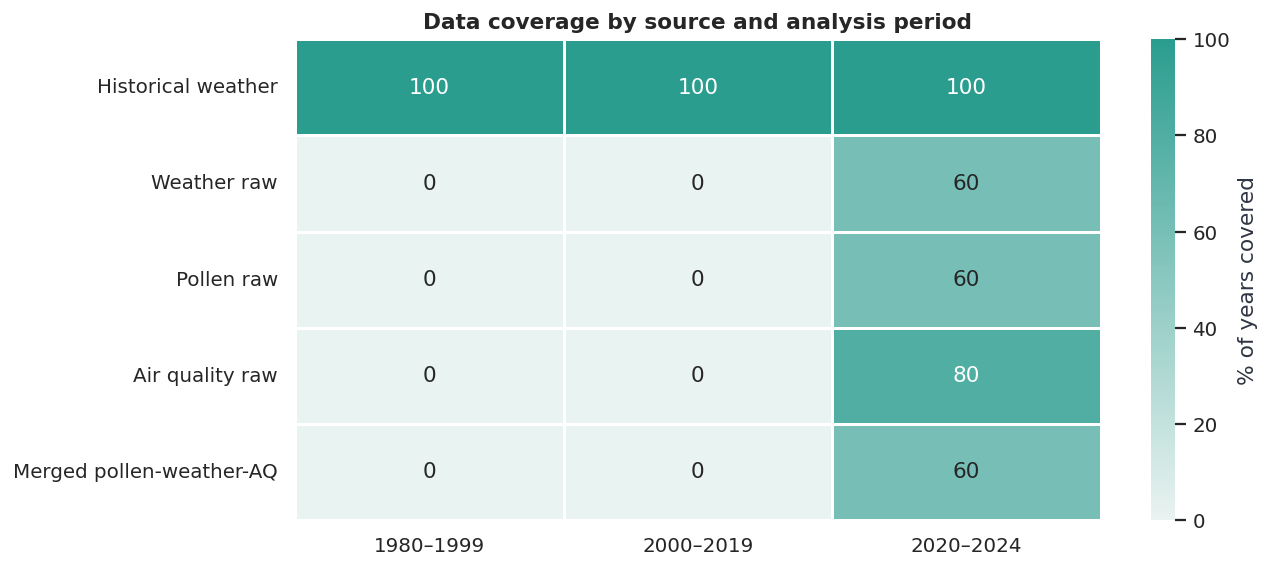

In [16]:
coverage_period_rows = []
for source_name, path in [
    ("Historical weather", HIST_WEATHER_PATH),
    ("Weather raw", WEATHER_RAW_PATH),
    ("Pollen raw", POLLEN_RAW_PATH),
    ("Air quality raw", AQ_RAW_PATH),
    ("Merged pollen-weather-AQ", MERGED_AQ_PATH),
]:
    if not path.exists():
        continue
    df_tmp = pd.read_csv(path, parse_dates=["date"])
    df_tmp["year"] = df_tmp["date"].dt.year
    df_tmp["period"] = df_tmp["year"].map(assign_period)
    years = (
        df_tmp.dropna(subset=["period"])
        .groupby(["period"], observed=True)["year"]
        .nunique()
        .reindex(PERIOD_ORDER, fill_value=0)
    )
    for period, years_observed in years.items():
        period_len = next(end - start + 1 for label, start, end in PERIODS if label == period)
        coverage_period_rows.append({
            "source": source_name,
            "period": period,
            "years_observed": years_observed,
            "period_years": period_len,
            "coverage_pct": 100 * years_observed / period_len,
        })

coverage_period = pd.DataFrame(coverage_period_rows)
coverage_matrix = coverage_period.pivot(index="source", columns="period", values="coverage_pct").reindex(
    ["Historical weather", "Weather raw", "Pollen raw", "Air quality raw", "Merged pollen-weather-AQ"]
)

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.heatmap(
    coverage_matrix,
    annot=True,
    fmt=".0f",
    cmap=sns.light_palette("#2a9d8f", as_cmap=True),
    vmin=0,
    vmax=100,
    linewidths=1.4,
    linecolor="white",
    cbar_kws={"label": "% of years covered"},
    ax=ax,
)
ax.set_title("Data coverage by source and analysis period")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
savefig(fig, "06_data_coverage_heatmap.png")
plt.show()

**Reading.** Only weather supports the full historical comparison. Pollen and AQ are kept as recent context for 2022–2024.

## 2 — Weather Evolution by Period

Weather indicators are aggregated by year first, then averaged by period. This makes leap years and unequal period lengths less distorting.

In [17]:
if not HIST_WEATHER_PATH.exists():
    raise FileNotFoundError(f"Missing {HIST_WEATHER_PATH}. Run the historical weather cache step first.")

weather = pd.read_csv(HIST_WEATHER_PATH, parse_dates=["date"])
weather["sunshine_hours"] = weather["sunshine_duration"] / 3600
weather["hot_day"] = weather["temperature_2m_max"] >= 30
weather["summer_day"] = weather["temperature_2m_max"] >= 25
weather["frost_day"] = weather["temperature_2m_min"] < 0
weather["wet_day"] = weather["precipitation_sum"] >= 1
weather["period"] = weather["year"].map(assign_period)
weather = weather.dropna(subset=["period"]).copy()
weather["period"] = pd.Categorical(weather["period"], PERIOD_ORDER, ordered=True)
weather.head()

,date,city,climate,year,month,day_of_year,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,...,relative_humidity_2m_mean,surface_pressure_mean,shortwave_radiation_sum,winddirection_10m_dominant,sunshine_hours,hot_day,summer_day,frost_day,wet_day,period
0,1980-01-01,Bordeaux,Oceanic,1980,1,1,5.4,7.9,3.4,6.0,...,91,1010.2,2.76,147,4.143914,False,False,False,True,1980–1999
1,1980-01-02,Bordeaux,Oceanic,1980,1,2,3.8,9.2,0.3,1.6,...,84,1020.6,4.28,347,4.001358,False,False,False,True,1980–1999
2,1980-01-03,Bordeaux,Oceanic,1980,1,3,1.1,4.1,-1.9,0.0,...,73,1025.6,6.53,133,8.000000,False,False,True,False,1980–1999
3,1980-01-04,Bordeaux,Oceanic,1980,1,4,6.5,12.7,1.2,0.3,...,81,1017.6,5.33,186,7.960614,False,False,False,False,1980–1999
4,1980-01-05,Bordeaux,Oceanic,1980,1,5,8.4,10.7,6.7,5.2,...,89,1016.3,5.56,274,8.082408,False,False,False,True,1980–1999


In [18]:
annual_weather = (
    weather.groupby(["city", "year", "period"], observed=True)
    .agg(
        temp_mean_c=("temperature_2m_mean", "mean"),
        temp_max_mean_c=("temperature_2m_max", "mean"),
        temp_min_mean_c=("temperature_2m_min", "mean"),
        precipitation_mm=("precipitation_sum", "sum"),
        wet_days=("wet_day", "sum"),
        hot_days=("hot_day", "sum"),
        summer_days=("summer_day", "sum"),
        frost_days=("frost_day", "sum"),
        sunshine_hours=("sunshine_hours", "sum"),
        windspeed_max_mean=("windspeed_10m_max", "mean"),
        humidity_mean_pct=("relative_humidity_2m_mean", "mean"),
    )
    .reset_index()
)
annual_weather["temp_mean_5y"] = annual_weather.groupby("city")["temp_mean_c"].transform(
    lambda s: s.rolling(5, center=True, min_periods=2).mean()
)

period_weather = (
    annual_weather.groupby(["city", "period"], observed=True)
    .agg(
        years=("year", "nunique"),
        temp_mean_c=("temp_mean_c", "mean"),
        temp_max_mean_c=("temp_max_mean_c", "mean"),
        temp_min_mean_c=("temp_min_mean_c", "mean"),
        precipitation_mm_per_year=("precipitation_mm", "mean"),
        wet_days_per_year=("wet_days", "mean"),
        hot_days_per_year=("hot_days", "mean"),
        summer_days_per_year=("summer_days", "mean"),
        frost_days_per_year=("frost_days", "mean"),
        sunshine_hours_per_year=("sunshine_hours", "mean"),
        windspeed_max_mean=("windspeed_max_mean", "mean"),
        humidity_mean_pct=("humidity_mean_pct", "mean"),
    )
    .reset_index()
)

baseline = period_weather[period_weather["period"] == "1980–1999"].set_index("city")
for col in ["temp_mean_c", "precipitation_mm_per_year", "hot_days_per_year", "sunshine_hours_per_year", "frost_days_per_year"]:
    period_weather[f"delta_{col}_vs_1980_1999"] = period_weather.apply(
        lambda row: row[col] - baseline.loc[row["city"], col], axis=1
    )

period_weather.to_csv(DATA_PROC / "06_weather_period_summary.csv", index=False)
period_weather.round(2)

,city,period,years,temp_mean_c,temp_max_mean_c,temp_min_mean_c,precipitation_mm_per_year,wet_days_per_year,hot_days_per_year,summer_days_per_year,frost_days_per_year,sunshine_hours_per_year,windspeed_max_mean,humidity_mean_pct,delta_temp_mean_c_vs_1980_1999,delta_precipitation_mm_per_year_vs_1980_1999,delta_hot_days_per_year_vs_1980_1999,delta_sunshine_hours_per_year_vs_1980_1999,delta_frost_days_per_year_vs_1980_1999
0,Bordeaux,1980–1999,20,13.42,17.91,9.31,773.06,123.60,17.30,65.90,25.15,3290.41,14.90,76.10,0.00,0.00,0.00,0.00,0.00
1,Bordeaux,2000–2019,20,13.89,18.47,9.72,761.93,122.85,24.00,75.55,22.55,3325.03,15.25,75.13,0.46,-11.13,6.70,34.61,-2.60
2,Bordeaux,2020–2024,5,14.38,19.05,10.30,1046.16,135.80,24.00,81.00,15.00,3122.69,16.92,77.26,0.95,273.10,6.70,-167.72,-10.15
3,Marseille,1980–1999,20,15.02,18.41,11.74,590.21,72.60,6.55,74.10,3.60,3774.00,20.06,72.83,0.00,0.00,0.00,0.00,0.00
4,Marseille,2000–2019,20,15.62,19.04,12.33,613.92,74.55,11.90,87.10,2.75,3814.89,20.97,71.26,0.60,23.71,5.35,40.89,-0.85
5,Marseille,2020–2024,5,15.89,19.39,12.47,528.44,69.80,17.60,89.00,0.20,3745.00,24.44,70.43,0.87,-61.77,11.05,-29.00,-3.40
6,Paris,1980–1999,20,11.05,14.86,7.34,678.46,128.20,4.35,29.40,44.75,2754.02,18.36,78.24,0.00,0.00,0.00,0.00,0.00
7,Paris,2000–2019,20,11.78,15.70,7.94,675.82,127.40,7.35,37.95,39.85,2856.87,18.16,76.95,0.72,-2.64,3.00,102.85,-4.90
8,Paris,2020–2024,5,12.51,16.66,8.49,843.92,143.80,12.20,52.00,29.40,2875.78,19.40,75.78,1.45,165.46,7.85,121.76,-15.35
9,Strasbourg,1980–1999,20,10.10,14.07,6.42,957.85,155.35,4.25,34.55,70.15,2930.88,13.19,76.89,0.00,0.00,0.00,0.00,0.00


In [19]:
overall_period_weather = (
    period_weather.groupby("period", observed=True)
    .agg(
        cities=("city", "nunique"),
        years_mean=("years", "mean"),
        temp_mean_c=("temp_mean_c", "mean"),
        precipitation_mm_per_year=("precipitation_mm_per_year", "mean"),
        hot_days_per_year=("hot_days_per_year", "mean"),
        frost_days_per_year=("frost_days_per_year", "mean"),
        sunshine_hours_per_year=("sunshine_hours_per_year", "mean"),
    )
    .reset_index()
)
overall_period_weather.to_csv(DATA_PROC / "06_weather_period_summary_all_cities.csv", index=False)
overall_period_weather.round(2)

,period,cities,years_mean,temp_mean_c,precipitation_mm_per_year,hot_days_per_year,frost_days_per_year,sunshine_hours_per_year
0,1980–1999,4,20.0,12.40,749.90,8.11,35.91,3187.33
1,2000–2019,4,20.0,13.08,737.04,13.60,31.88,3267.25
2,2020–2024,4,5.0,13.68,848.56,17.20,23.05,3189.17


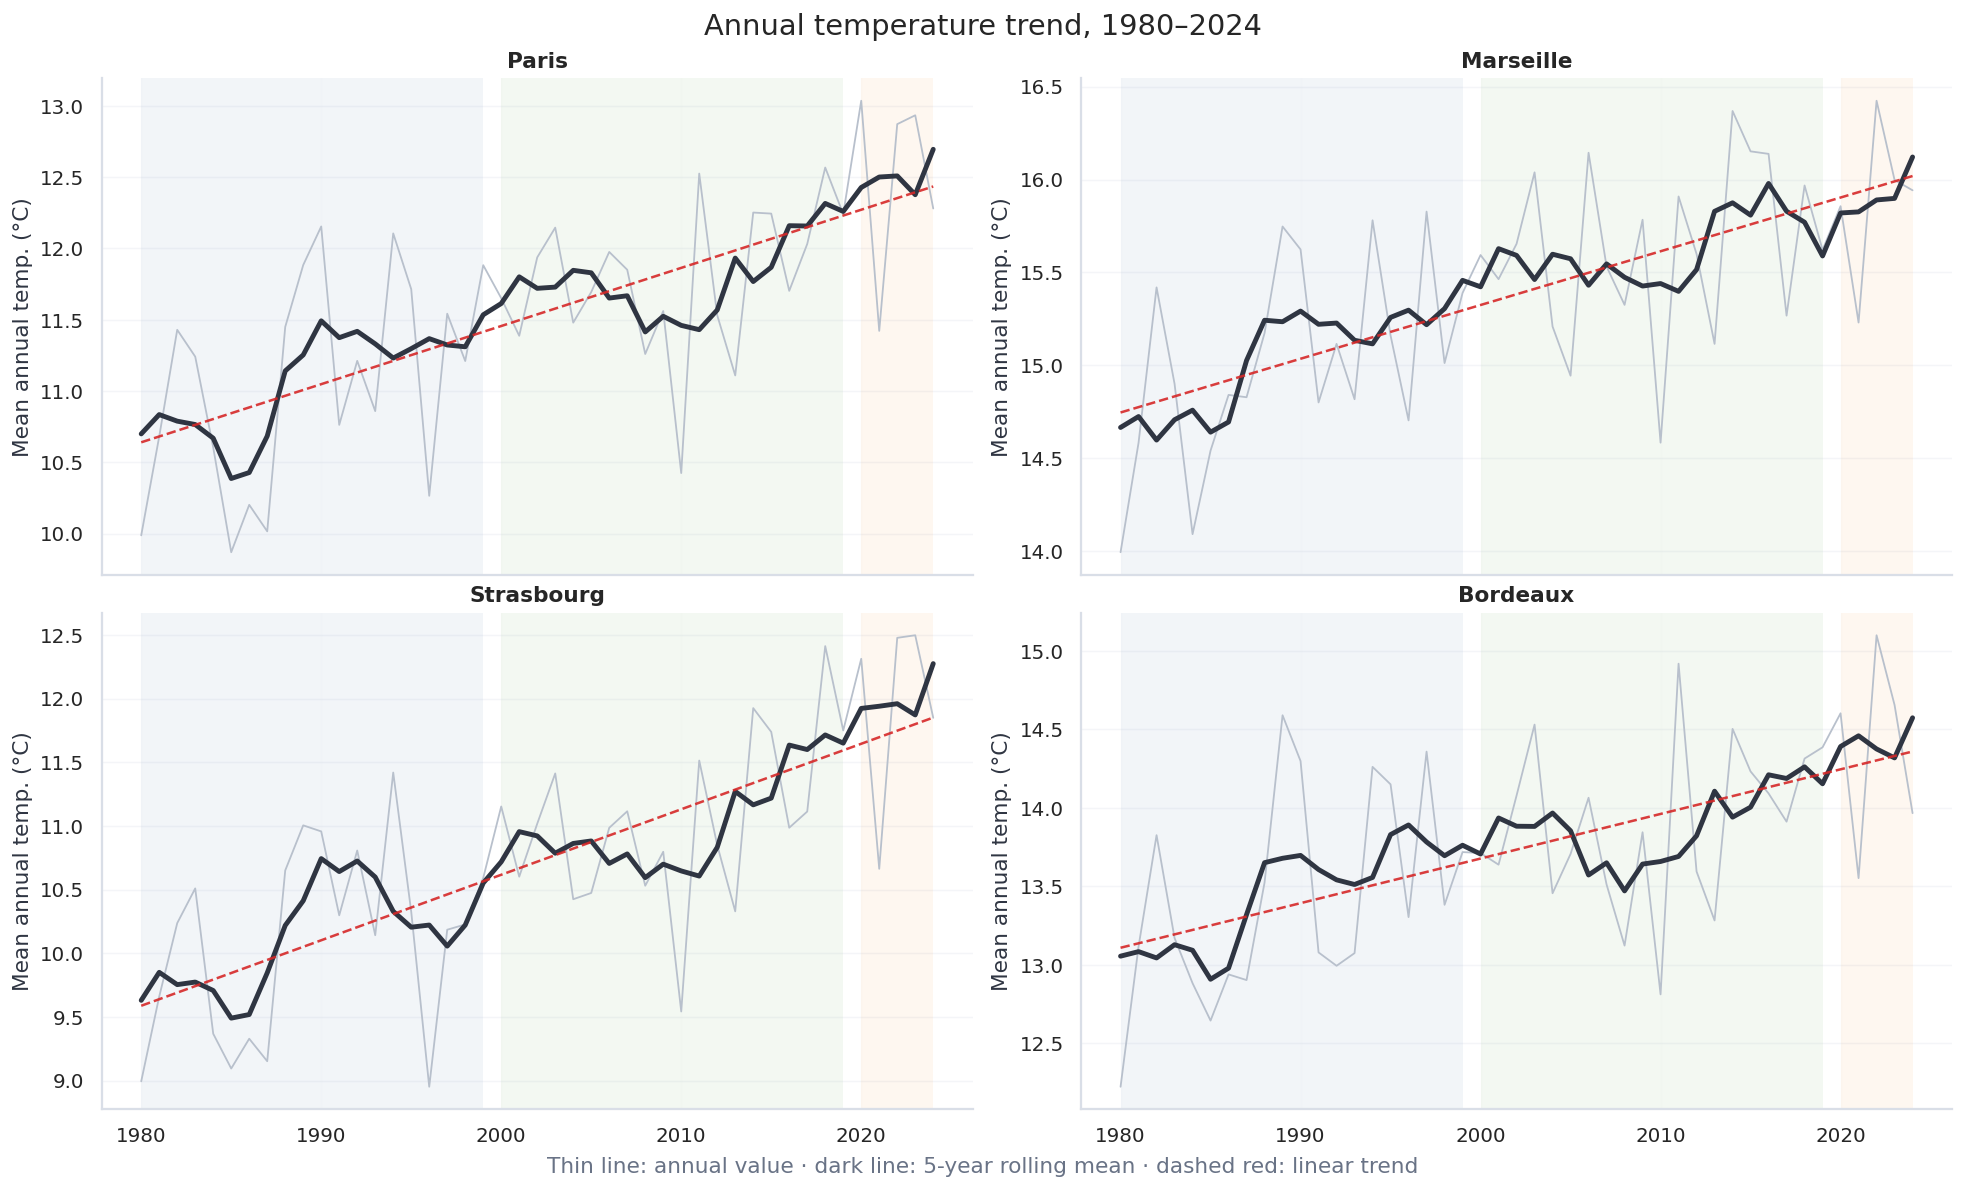

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharex=True, constrained_layout=True)
axes = axes.ravel()

for ax, city in zip(axes, CITY_ORDER):
    city_df = annual_weather[annual_weather["city"] == city]
    for label, start, end in PERIODS:
        ax.axvspan(start, end, color=PERIOD_PALETTE[label], alpha=0.07, lw=0)
    sns.lineplot(
        data=city_df,
        x="year",
        y="temp_mean_c",
        ax=ax,
        color="#b8c0cc",
        linewidth=1.0,
        estimator=None,
    )
    sns.lineplot(
        data=city_df,
        x="year",
        y="temp_mean_5y",
        ax=ax,
        color="#2f3542",
        linewidth=2.7,
        estimator=None,
    )
    sns.regplot(
        data=city_df,
        x="year",
        y="temp_mean_c",
        ax=ax,
        scatter=False,
        color="#d62828",
        line_kws={"linewidth": 1.4, "linestyle": "--", "alpha": 0.9},
        ci=None,
    )
    ax.set_title(city)
    ax.set_xlabel("")
    ax.set_ylabel("Mean annual temp. (°C)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    clean_axis(ax)

fig.suptitle("Annual temperature trend, 1980–2024", fontsize=16, y=1.03)
fig.text(0.5, -0.02, "Thin line: annual value · dark line: 5-year rolling mean · dashed red: linear trend", ha="center", color="#697386")
savefig(fig, "06_annual_temperature_trends.png")
plt.show()

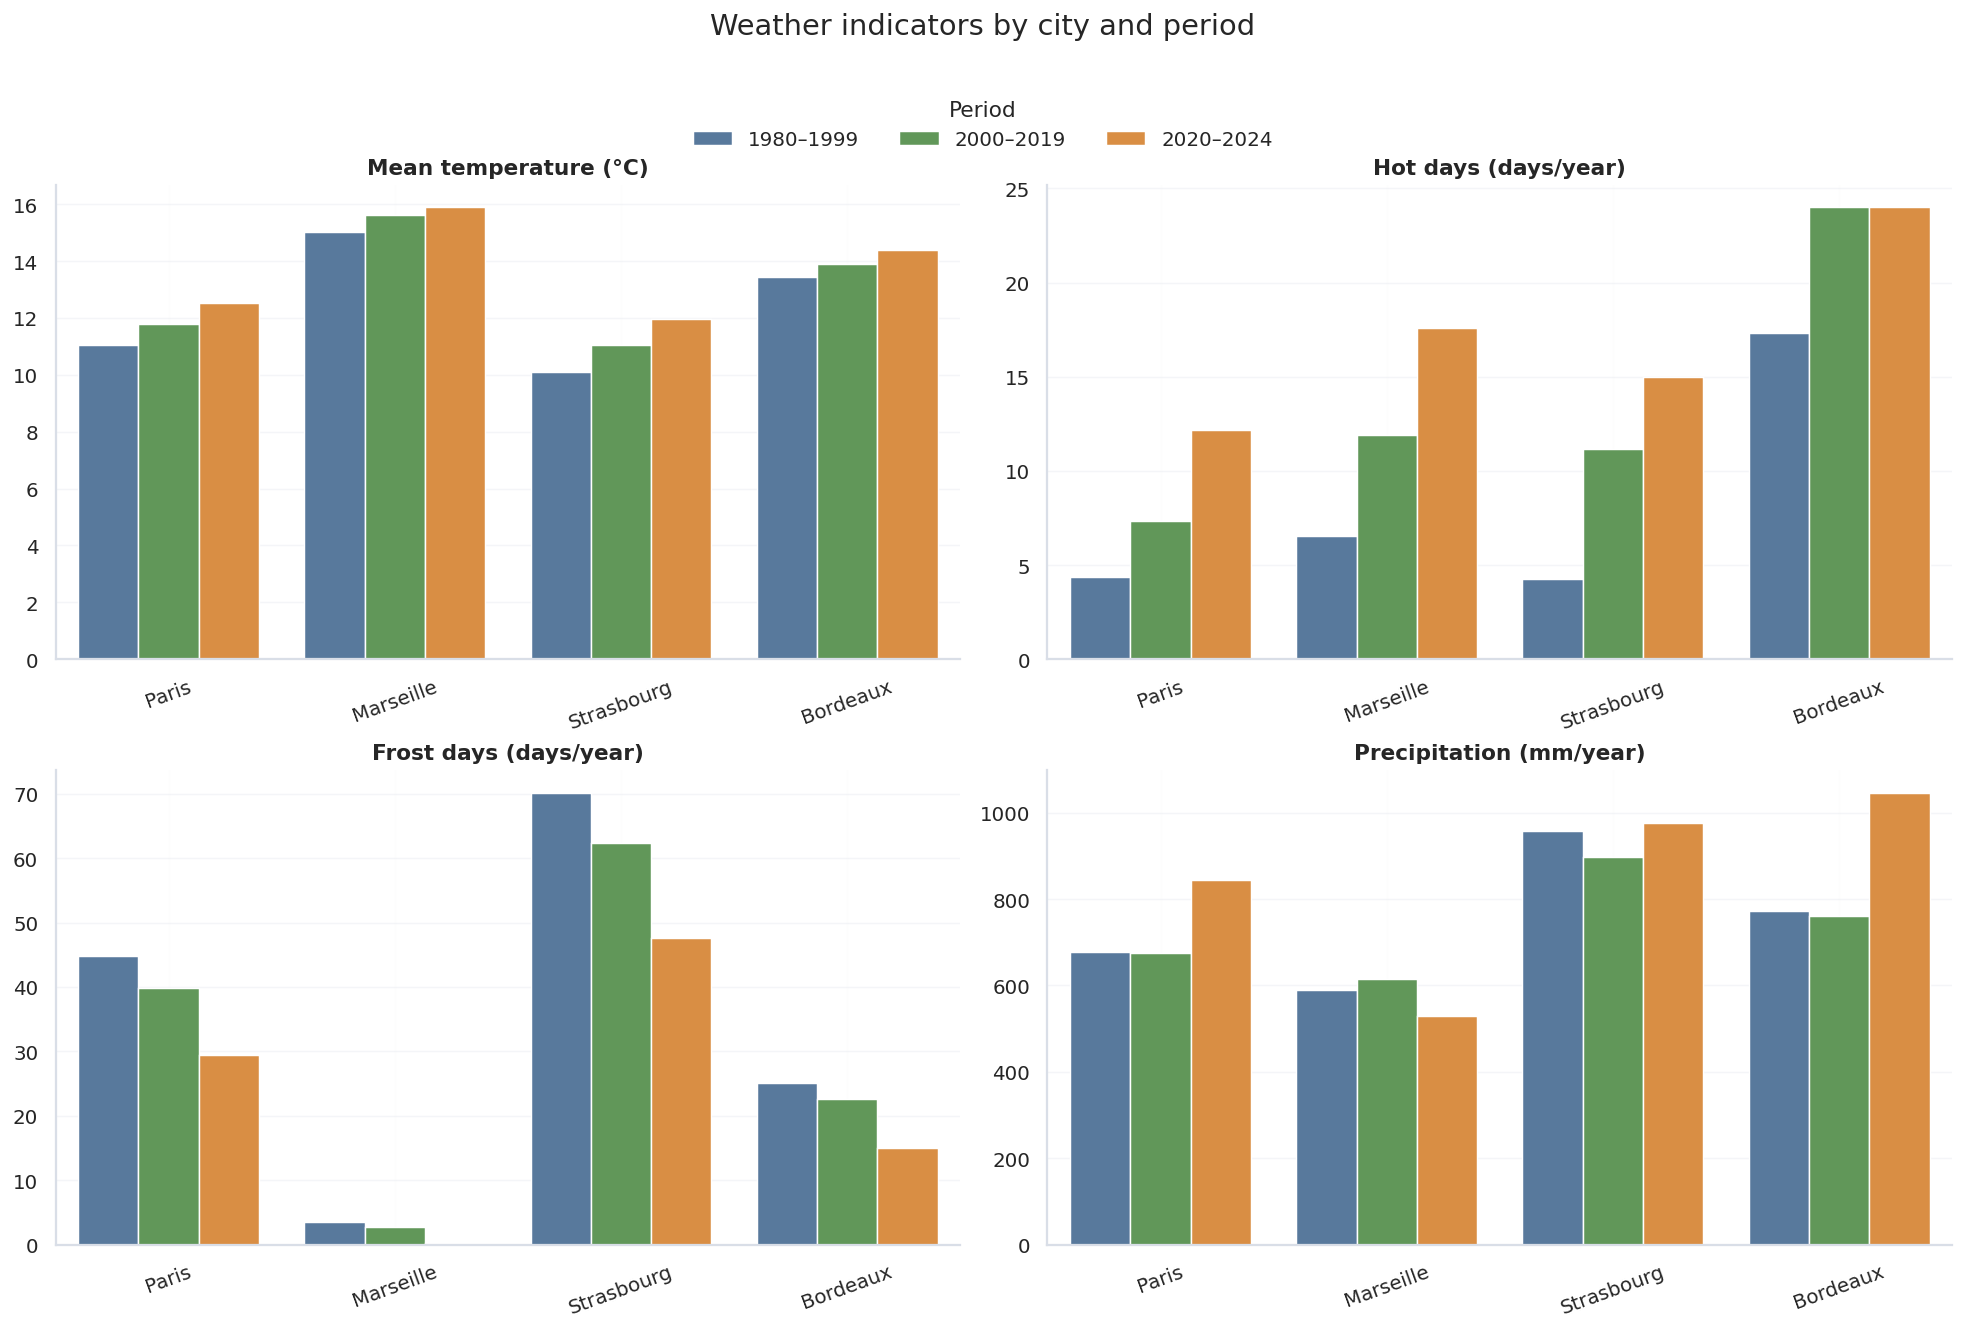

In [21]:
plot_metrics = pd.DataFrame([
    {"metric": "Mean temperature", "column": "temp_mean_c", "unit": "°C"},
    {"metric": "Hot days", "column": "hot_days_per_year", "unit": "days/year"},
    {"metric": "Frost days", "column": "frost_days_per_year", "unit": "days/year"},
    {"metric": "Precipitation", "column": "precipitation_mm_per_year", "unit": "mm/year"},
])

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
axes = axes.ravel()

for ax, row in zip(axes, plot_metrics.itertuples(index=False)):
    sns.barplot(
        data=period_weather,
        x="city",
        y=row.column,
        hue="period",
        order=CITY_ORDER,
        hue_order=PERIOD_ORDER,
        palette=PERIOD_PALETTE,
        ax=ax,
        edgecolor="white",
        linewidth=0.8,
    )
    ax.set_title(f"{row.metric} ({row.unit})")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.legend_.remove()
    clean_axis(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Period", loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.06))
fig.suptitle("Weather indicators by city and period", fontsize=16, y=1.12)
savefig(fig, "06_weather_period_evolution.png")
plt.show()

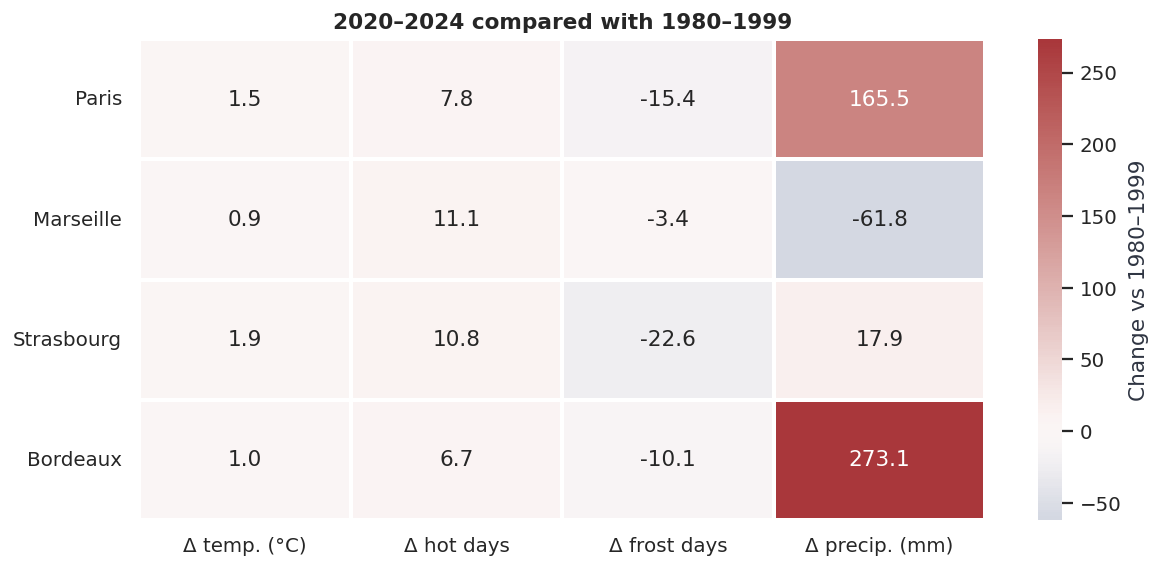

In [22]:
delta_cols = {
    "Δ temp. (°C)": "delta_temp_mean_c_vs_1980_1999",
    "Δ hot days": "delta_hot_days_per_year_vs_1980_1999",
    "Δ frost days": "delta_frost_days_per_year_vs_1980_1999",
    "Δ precip. (mm)": "delta_precipitation_mm_per_year_vs_1980_1999",
}
latest_delta = period_weather[period_weather["period"] == "2020–2024"].set_index("city")
delta_matrix = pd.DataFrame({label: latest_delta[col] for label, col in delta_cols.items()}).loc[CITY_ORDER]

fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.heatmap(
    delta_matrix,
    annot=True,
    fmt=".1f",
    cmap="vlag",
    center=0,
    linewidths=1.2,
    linecolor="white",
    cbar_kws={"label": "Change vs 1980–1999"},
    ax=ax,
)
ax.set_title("2020–2024 compared with 1980–1999")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
savefig(fig, "06_weather_delta_heatmap.png")
plt.show()

**Reading.** The recent block is warmer in every city. Hot days increase, while frost days decrease sharply, especially in the continental cities.

## 3 — Recent Pollen and Air Quality Context

These plots use only the observed 2022–2024 overlap. They help describe the recent allergy-risk context, not historical pollen/AQ evolution.

In [23]:
merged = pd.read_csv(MERGED_AQ_PATH, parse_dates=["date"])
merged["total_pollen"] = merged[POLLEN_COLS].sum(axis=1)
merged["year"] = merged["date"].dt.year
merged["period"] = merged["year"].map(assign_period)

recent_coverage = (
    merged.groupby("city")
    .agg(start=("date", "min"), end=("date", "max"), days=("date", "nunique"))
    .reset_index()
)
recent_coverage["start"] = recent_coverage["start"].dt.date
recent_coverage["end"] = recent_coverage["end"].dt.date
recent_coverage

,city,start,end,days
0,Bordeaux,2022-01-01,2024-12-31,1096
1,Marseille,2022-01-01,2024-12-31,1096
2,Paris,2022-01-01,2024-12-31,1096
3,Strasbourg,2022-01-01,2024-12-31,1096


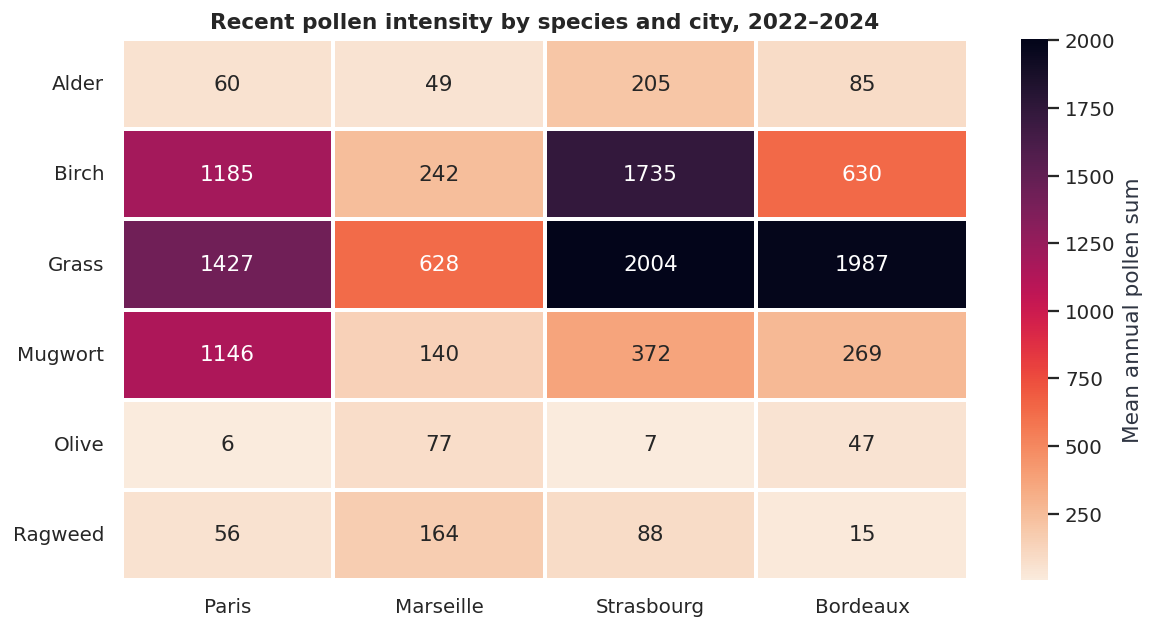

In [24]:
pollen_long = merged.melt(
    id_vars=["date", "city", "year"],
    value_vars=POLLEN_COLS,
    var_name="species",
    value_name="concentration",
)
pollen_long["species"] = pollen_long["species"].str.replace("_pollen", "", regex=False).str.title()

annual_pollen = (
    pollen_long.groupby(["city", "species", "year"])
    .agg(
        annual_sum=("concentration", "sum"),
        mean_daily=("concentration", "mean"),
        active_days=("concentration", lambda s: int((s > 0).sum())),
        peak_daily=("concentration", "max"),
    )
    .reset_index()
)

pollen_recent_summary = (
    annual_pollen.groupby(["city", "species"])
    .agg(
        years=("year", "nunique"),
        mean_annual_sum=("annual_sum", "mean"),
        mean_active_days=("active_days", "mean"),
        max_peak_daily=("peak_daily", "max"),
    )
    .reset_index()
)
pollen_recent_summary.to_csv(DATA_PROC / "06_pollen_recent_summary_2022_2024.csv", index=False)

pollen_heatmap = pollen_recent_summary.pivot(index="species", columns="city", values="mean_annual_sum")[CITY_ORDER]

fig, ax = plt.subplots(figsize=(10.5, 5.4))
sns.heatmap(
    pollen_heatmap,
    cmap=sns.color_palette("rocket_r", as_cmap=True),
    annot=True,
    fmt=".0f",
    linewidths=1.2,
    linecolor="white",
    cbar_kws={"label": "Mean annual pollen sum"},
    ax=ax,
)
ax.set_title("Recent pollen intensity by species and city, 2022–2024")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
savefig(fig, "06_recent_pollen_heatmap.png")
plt.show()

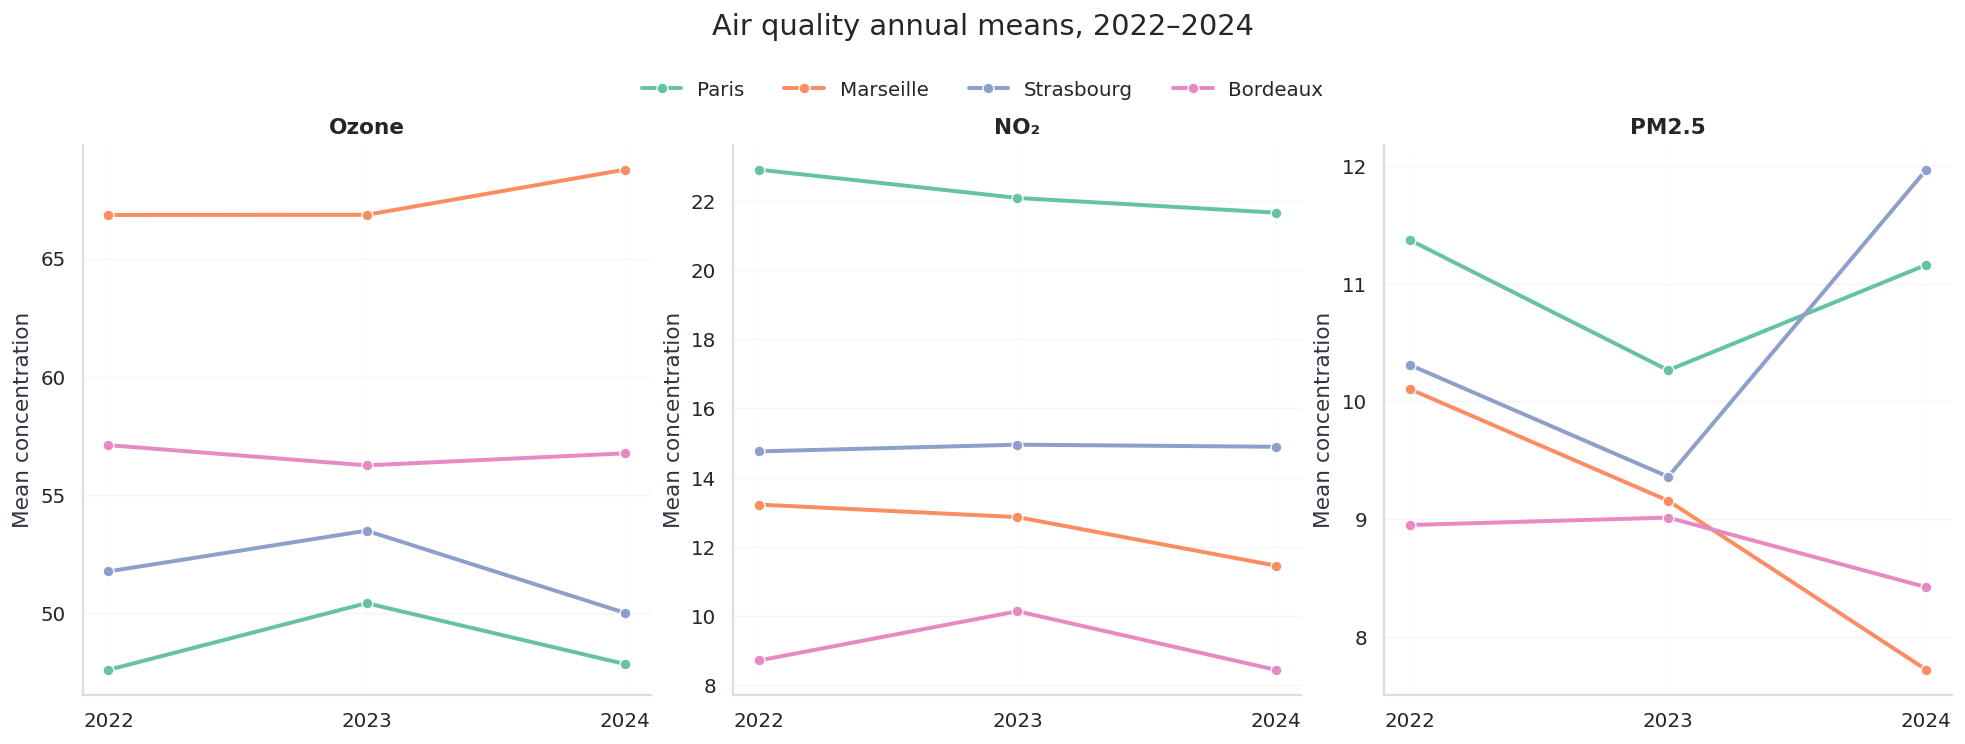

In [25]:
aq_recent = (
    merged.groupby(["city", "year"])
    .agg(
        ozone_mean=("ozone", "mean"),
        nitrogen_dioxide_mean=("nitrogen_dioxide", "mean"),
        pm2_5_mean=("pm2_5", "mean"),
        ozone_p95=("ozone", lambda s: s.quantile(0.95)),
        nitrogen_dioxide_p95=("nitrogen_dioxide", lambda s: s.quantile(0.95)),
        pm2_5_p95=("pm2_5", lambda s: s.quantile(0.95)),
    )
    .reset_index()
)
aq_recent.to_csv(DATA_PROC / "06_aq_recent_summary_2022_2024.csv", index=False)

aq_long = aq_recent.melt(
    id_vars=["city", "year"],
    value_vars=["ozone_mean", "nitrogen_dioxide_mean", "pm2_5_mean"],
    var_name="pollutant",
    value_name="mean_concentration",
)
aq_long["pollutant"] = aq_long["pollutant"].map({
    "ozone_mean": "Ozone",
    "nitrogen_dioxide_mean": "NO₂",
    "pm2_5_mean": "PM2.5",
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, constrained_layout=True)
for ax, pollutant in zip(axes, ["Ozone", "NO₂", "PM2.5"]):
    sub = aq_long[aq_long["pollutant"] == pollutant]
    sns.lineplot(
        data=sub,
        x="year",
        y="mean_concentration",
        hue="city",
        hue_order=CITY_ORDER,
        palette=CITY_PALETTE,
        marker="o",
        linewidth=2.2,
        ax=ax,
    )
    ax.set_title(pollutant)
    ax.set_xlabel("")
    ax.set_ylabel("Mean concentration")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend_.remove()
    clean_axis(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Air quality annual means, 2022–2024", fontsize=16, y=1.16)
savefig(fig, "06_recent_aq_lines.png")
plt.show()

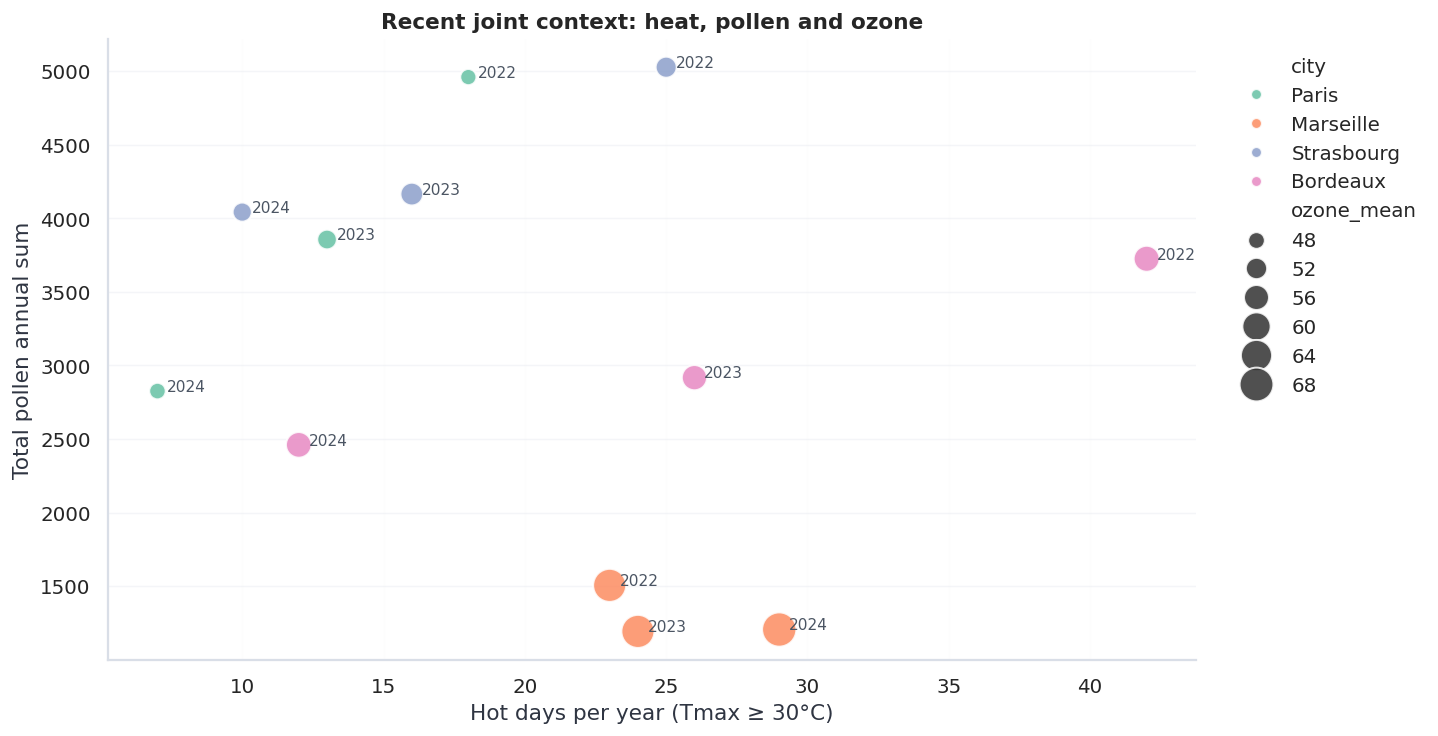

In [26]:
recent_city_year = (
    merged.groupby(["city", "year"])
    .agg(
        total_pollen_sum=("total_pollen", "sum"),
        temp_max_mean=("temperature_2m_max", "mean"),
        hot_days=("temperature_2m_max", lambda s: int((s >= 30).sum())),
        ozone_mean=("ozone", "mean"),
        pm2_5_mean=("pm2_5", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10.8, 6.2))
sns.scatterplot(
    data=recent_city_year,
    x="hot_days",
    y="total_pollen_sum",
    hue="city",
    hue_order=CITY_ORDER,
    size="ozone_mean",
    sizes=(80, 360),
    palette=CITY_PALETTE,
    alpha=0.86,
    edgecolor="white",
    linewidth=1.1,
    ax=ax,
)
for _, row in recent_city_year.iterrows():
    ax.text(row["hot_days"] + 0.35, row["total_pollen_sum"], str(int(row["year"])), fontsize=8.5, color="#4b5563")
ax.set_title("Recent joint context: heat, pollen and ozone")
ax.set_xlabel("Hot days per year (Tmax ≥ 30°C)")
ax.set_ylabel("Total pollen annual sum")
clean_axis(ax)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
savefig(fig, "06_recent_heat_pollen_aq_scatter.png")
plt.show()

**Reading.** Grass dominates recent pollen load in most cities. AQ varies by pollutant and city, so it is best treated as a contextual layer rather than a long-term trend here.

## 4 — Factual Takeaways

The summary below is generated from the period tables, keeping the conclusion tied to the data.

In [27]:
latest = period_weather[period_weather["period"] == "2020–2024"].set_index("city")
first = period_weather[period_weather["period"] == "1980–1999"].set_index("city")

takeaways_df = pd.DataFrame([
    {
        "city": city,
        "temp_delta_2020_2024_vs_1980_1999_c": latest.loc[city, "temp_mean_c"] - first.loc[city, "temp_mean_c"],
        "hot_days_delta_per_year": latest.loc[city, "hot_days_per_year"] - first.loc[city, "hot_days_per_year"],
        "frost_days_delta_per_year": latest.loc[city, "frost_days_per_year"] - first.loc[city, "frost_days_per_year"],
    }
    for city in CITY_ORDER
])
takeaways_df.to_csv(DATA_PROC / "06_key_weather_deltas.csv", index=False)

print("Factual scope")
print("- Weather supports a 1980–2024 comparison for all four cities.")
print("- Pollen and AQ support a 2022–2024 observed-context summary only.")
print("\nWeather deltas, 2020–2024 vs 1980–1999:")
display(takeaways_df.round(2))

Factual scope
- Weather supports a 1980–2024 comparison for all four cities.
- Pollen and AQ support a 2022–2024 observed-context summary only.

Weather deltas, 2020–2024 vs 1980–1999:


,city,temp_delta_2020_2024_vs_1980_1999_c,hot_days_delta_per_year,frost_days_delta_per_year
0,Paris,1.45,7.85,-15.35
1,Marseille,0.87,11.05,-3.40
2,Strasbourg,1.86,10.75,-22.55
3,Bordeaux,0.95,6.70,-10.15


## 5 — Exported Artifacts

Tables are saved in `Data/processed/`. Figures are saved in `figures/` with the `06_` prefix.

Main figures: coverage heatmap, temperature trends, period indicators, weather deltas, pollen heatmap, AQ lines, and heat-pollen-AQ scatter.